In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Symbolic Construction of Polynomial Chaos for Gaussian Random Variables


Consider the random variable:

$$
\Xi \sim N(0,1).
$$

The correct Hilbert space is:

$$
L^2(\Xi) = \left\{ f:\mathbb{R} \mapsto \mathbb{R} \middle| \mathbb{E}\left[f^2(\Xi)\right]\right\}.
$$

The inner product is:

$$
\langle f, g \rangle = \mathbb{E}\left[f(\Xi)g(\Xi)\right] = \int_{-\infty}^{\infty} f(\xi)g(\xi) \frac{1}{\sqrt{2\pi}} e^{-\frac{\xi^2}{2}} d\xi.
$$

Again, we will follow the Gram-Schmidt procedure to construct an orthonormal basis for this space.
We start with the monomials: $\{1, \xi, \xi^2, \ldots\}$.



In [3]:
import sympy
from sympy import pprint
sympy.init_printing()

xi = sympy.symbols('xi')

inner_product = lambda f, g: sympy.integrate(
    f * g  * sympy.exp(-xi ** 2 / 2) / sympy.sqrt(2 * sympy.pi),
    (xi, -sympy.oo, sympy.oo)
)
norm = lambda f: sympy.sqrt(inner_product(f, f))

def gram_schmidt(fs):
    gs = []
    for f in fs:
        g = f
        for h in gs:
            g -= inner_product(f, h) / inner_product(h, h) * h
        gs.append(g / norm(g))
    return gs

num_terms = 10
fs = [xi**i for i in range(num_terms)]
gs = gram_schmidt(fs)

for f in gs:
    pprint(f)

1
ξ
   ⎛ 2    ⎞
√2⋅⎝ξ  - 1⎠
───────────
     2     
   ⎛ 3      ⎞
√6⋅⎝ξ  - 3⋅ξ⎠
─────────────
      6      
   ⎛ 4      2    ⎞
√6⋅⎝ξ  - 6⋅ξ  + 3⎠
──────────────────
        12        
    ⎛ 5       3       ⎞
√30⋅⎝ξ  - 10⋅ξ  + 15⋅ξ⎠
───────────────────────
          60           
   ⎛ 6       4       2     ⎞
√5⋅⎝ξ  - 15⋅ξ  + 45⋅ξ  - 15⎠
────────────────────────────
             60             
    ⎛ 7       5        3        ⎞
√35⋅⎝ξ  - 21⋅ξ  + 105⋅ξ  - 105⋅ξ⎠
─────────────────────────────────
               420               
    ⎛ 8       6        4        2      ⎞
√70⋅⎝ξ  - 28⋅ξ  + 210⋅ξ  - 420⋅ξ  + 105⎠
────────────────────────────────────────
                  1680                  
    ⎛ 9       7        5         3        ⎞
√70⋅⎝ξ  - 36⋅ξ  + 378⋅ξ  - 1260⋅ξ  + 945⋅ξ⎠
───────────────────────────────────────────
                   5040                    


Now let's turn them to jax functions:

In [4]:
from jax import vmap, jit
from functools import partial
import jax.numpy as jnp

@partial(jit, static_argnums=(1, 2))
@partial(vmap, in_axes=(0,))
def basis(xi, xi_sym=xi, es_sym=gs):
    return jnp.array([
        sympy.lambdify(xi_sym, e, 'numpy')(xi)
        for e in es_sym
    ])

In [5]:
xis = jnp.linspace(-3, 3, 1000)
basis_values = basis(xis)
basis_values.shape

Here they are:

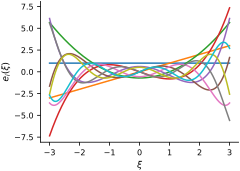

In [6]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(xis, basis_values)
ax.set(xlabel=r'$\xi$', ylabel=r'$e_i(\xi)$');

These are the Hermite polynomials.